# Generative AI Foundations and Applications
## A Programme by TalentSprint
### Notebook 2: Leveraging LLMs for Querying Insights (Data Loading)

## Learning Objectives

At the end of the experiment, you will be able to:

* load data from pickle files
* store the data in a SQLite database
* use LLMs to create chains for querying insights from this database

## Data Description

There are 2 pickle files which will be downloaded once you run the below cell:

> - *constituent_stock_prices.pkl*
>
>    It contains information related to stock prices - open, high, low, close, volume

> - *constituent_stock_fundamentals.pkl*
>
>    It contains information related to fundamentals - income statement, balancesheet statement, cashflow statement


In [ ]:
#@title Download the pickle files
from IPython.display import clear_output
!gdown https://drive.google.com/uc?id=1c3eVGtfBlg9slenmz_DJkJJlH0zwKzlZ
!gdown https://drive.google.com/uc?id=1U8p04e43oHFh_tx-nNy5AGxmQtceBEqn
clear_output()

!ls | grep '.pkl'

constituent_stock_fundamentals.pkl
constituent_stock_prices.pkl


# Load Constituent Stock Prices data

In [ ]:
import pickle
import pandas as pd

csp = pickle.load(open('/content/constituent_stock_prices.pkl', 'rb'))

In [ ]:
type(csp)

dict

In [ ]:
csp.keys()    # each key contains a dataframe

dict_keys(['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BEL.NS', 'BPCL.NS', 'BHARTIARTL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ITC.NS', 'INDUSINDBK.NS', 'INFY.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS', 'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TCS.NS', 'TATACONSUM.NS', 'TATAMOTORS.NS', 'TATASTEEL.NS', 'TECHM.NS', 'TITAN.NS', 'TRENT.NS', 'ULTRACEMCO.NS', 'WIPRO.NS'])

In [ ]:
len(csp.keys())

50

In [ ]:
rows = []
cols = []

for key in csp.keys():
    print(csp[key].shape)
    rows.append(csp[key].shape[0])
    cols.append(csp[key].shape[1])

(5538, 5)
(4162, 5)
(5536, 5)
(5536, 5)
(6472, 5)
(5539, 5)
(5536, 5)
(5505, 5)
(5536, 5)
(7230, 5)
(5536, 5)
(7233, 5)
(7233, 5)
(3439, 5)
(7231, 5)
(7231, 5)
(5536, 5)
(5510, 5)
(7234, 5)
(1707, 5)
(5536, 5)
(7234, 5)
(7234, 5)
(5536, 5)
(7231, 5)
(5537, 5)
(7234, 5)
(5316, 5)
(5798, 5)
(5539, 5)
(7232, 5)
(5272, 5)
(4925, 5)
(5509, 5)
(7231, 5)
(4198, 5)
(7231, 5)
(1739, 5)
(5539, 5)
(7232, 5)
(7234, 5)
(5507, 5)
(7231, 5)
(8537, 5)
(7234, 5)
(4473, 5)
(7234, 5)
(5536, 5)
(5506, 5)
(7234, 5)


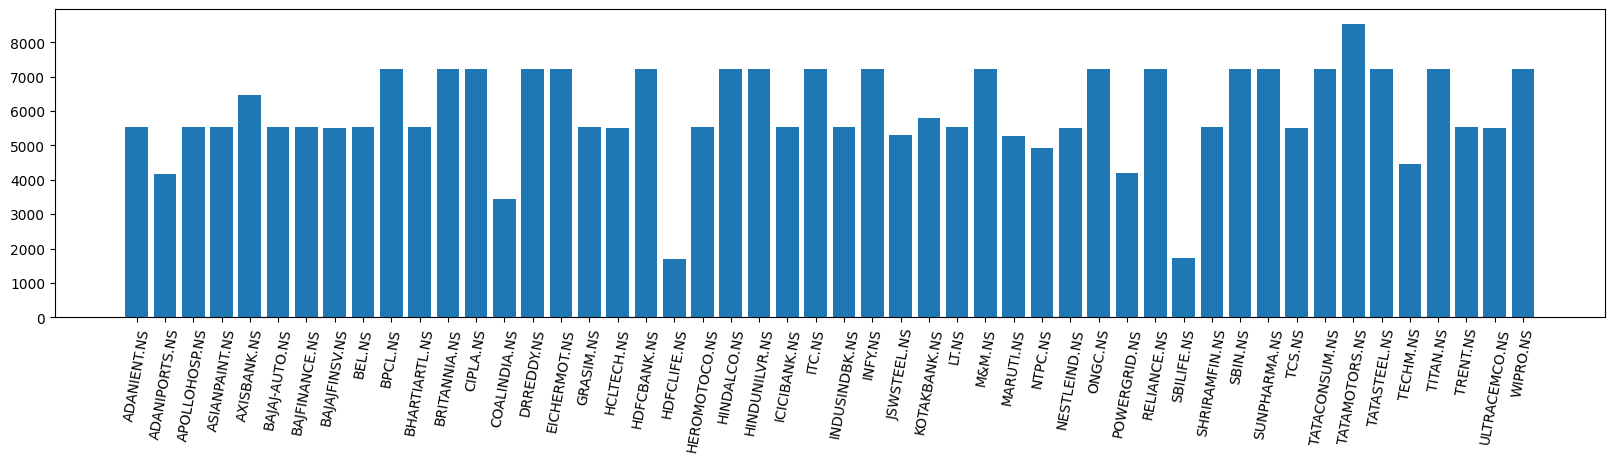

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
plt.bar(csp.keys(), rows)
plt.xticks(rotation=80)
plt.show()

In [ ]:
adani = csp['ADANIENT.NS']
print(adani.shape)
adani.head()

(5538, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2002-07-01,1.364148,1.401700,1.334259,1.362615,1080397
2002-07-02,1.386372,1.390971,1.356484,1.373344,1016147
2002-07-03,1.371811,1.387139,1.364914,1.373344,980394
2002-07-04,1.379475,1.401700,1.379475,1.381008,972747
2002-07-05,1.388672,1.388672,1.372578,1.377942,974496


In [ ]:
tcs = csp['TCS.NS']
print(tcs.shape)
tcs.head()

(5507, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2002-08-12,38.724998,40.000000,38.724998,39.700001,212976
2002-08-13,39.750000,40.387501,38.875000,39.162498,153576
2002-08-14,39.250000,39.250000,35.724998,36.462502,822776
2002-08-15,36.462502,36.462502,36.462502,36.462502,0
2002-08-16,36.275002,38.000000,35.750000,36.375000,811856


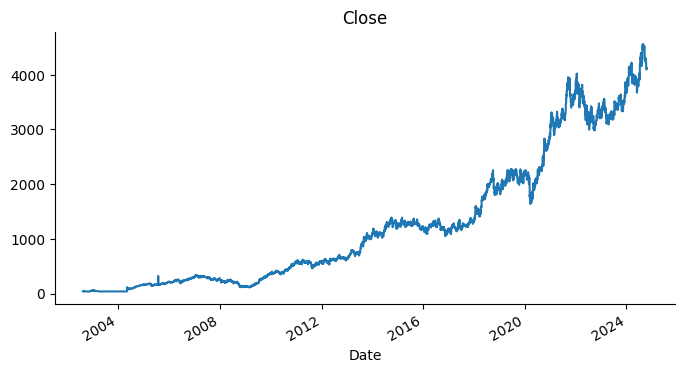

In [ ]:
from matplotlib import pyplot as plt
tcs['Close'].plot(kind='line', figsize=(8, 4), title='Close')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
wipro = csp['WIPRO.NS']
print(wipro.shape)
wipro.head()

(7234, 5)


,Open,High,Low,Close,Volume
Date,,,,,
1996-01-01,1.1250,1.1250,1.1250,1.1250,19999
1996-01-02,1.0375,1.0375,1.0375,1.0375,39999
1996-01-03,1.0750,1.0750,1.0750,1.0750,19999
1996-01-04,1.0750,1.0750,1.0750,1.0750,119999
1996-01-05,1.0750,1.0750,1.0750,1.0750,0


## **Combine Prices(OHLC) data**

In [ ]:
comb_df = pd.DataFrame(columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol'])

for key in csp.keys():
    tmp_df = csp[key].copy()
    tmp_df.reset_index(inplace=True)
    tmp_df['Symbol'] = key.split('.')[0]
    comb_df = pd.concat([comb_df, tmp_df], ignore_index=True)


/tmp/ipython-input-3382019963.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comb_df = pd.concat([comb_df, tmp_df], ignore_index=True)


In [ ]:
comb_df.head()

,Date,Open,High,Low,Close,Volume,Symbol
0,2002-07-01,1.364148,1.401700,1.334259,1.362615,1080397,ADANIENT
1,2002-07-02,1.386372,1.390971,1.356484,1.373344,1016147,ADANIENT
2,2002-07-03,1.371811,1.387139,1.364914,1.373344,980394,ADANIENT
3,2002-07-04,1.379475,1.401700,1.379475,1.381008,972747,ADANIENT
4,2002-07-05,1.388672,1.388672,1.372578,1.377942,974496,ADANIENT


In [ ]:
comb_df.shape

(298509, 7)

In [ ]:
sum(rows)

298509

In [ ]:
comb_df.tail()

,Date,Open,High,Low,Close,Volume,Symbol
298504,2024-10-11,520.349976,534.400024,520.349976,528.299988,4218491,WIPRO
298505,2024-10-14,538.700012,551.849976,536.299988,549.549988,16568133,WIPRO
298506,2024-10-15,552.849976,552.849976,530.849976,532.950012,10800626,WIPRO
298507,2024-10-16,533.000000,538.799988,529.000000,532.150024,6276811,WIPRO
298508,2024-10-18,532.000000,558.400024,524.799988,550.849976,20158218,WIPRO


In [ ]:
comb_df.to_csv('all_stock_prices.csv', index=False)

## **Create a SQLite Database (in-memory)**

In [ ]:
import sqlite3

In [ ]:
# Read DB (It will create if it doesn't exists)

conn = sqlite3.connect('stock_db.sqlite')
print("Opened database successfully");

Opened database successfully


In [ ]:
comb_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol'], dtype='object')

### Create table **`stock_prices`**

In [ ]:
# Create table 'stock_prices' in DB

conn.execute('''
CREATE TABLE IF NOT EXISTS stock_prices(
                      date DATE,
                      open DOUBLE,
                      high DOUBLE,
                      low DOUBLE,
                      close DOUBLE,
                      volume INT,
                      symbol VARCHAR(20));''')

conn.commit()

print("Table created successfully");

Table created successfully


In [ ]:
# Show tables

cursor = conn.execute('''
SELECT name FROM sqlite_master WHERE type='table';
''')

for row in cursor:
    print(row)

('stock_prices',)


### Insert data into **`stock_prices`** table

In [ ]:
def convert_date(date):
    yyyy = date.year
    mm = date.month
    dd = date.day
    if mm<10:
        mm = '0' + str(mm)

    if dd<10:
        dd = '0' + str(dd)
    return f"{yyyy}-{mm}-{dd}"

In [ ]:
convert_date(comb_df['Date'][0])

'2002-07-01'

In [ ]:
comb_df['Date'] = comb_df['Date'].apply(convert_date)
comb_df.head(3)

,Date,Open,High,Low,Close,Volume,Symbol
0,2002-07-01,1.364148,1.401700,1.334259,1.362615,1080397,ADANIENT
1,2002-07-02,1.386372,1.390971,1.356484,1.373344,1016147,ADANIENT
2,2002-07-03,1.371811,1.387139,1.364914,1.373344,980394,ADANIENT


In [ ]:
# Insert stock prices data

conn.executemany('''
INSERT INTO stock_prices (date, open, high, low, close, volume, symbol) VALUES (?, ?, ?, ?, ?, ?, ?)
''', comb_df.values)

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


### **Query the Database**

In [ ]:
# Show table content

cursor = conn.execute('''
SELECT * from stock_prices limit 10;
''')

for row in cursor:
    print(row)

('2002-07-01', 1.3641480207443237, 1.4017000198364258, 1.334259033203125, 1.3626149892807007, 1080397, 'ADANIENT')
('2002-07-02', 1.3863719701766968, 1.3909709453582764, 1.356484055519104, 1.3733439445495605, 1016147, 'ADANIENT')
('2002-07-03', 1.371811032295227, 1.3871389627456665, 1.3649139404296875, 1.3733439445495605, 980394, 'ADANIENT')
('2002-07-04', 1.3794749975204468, 1.4017000198364258, 1.3794749975204468, 1.3810080289840698, 972747, 'ADANIENT')
('2002-07-05', 1.3886719942092896, 1.3886719942092896, 1.3725780248641968, 1.3779419660568237, 974496, 'ADANIENT')
('2002-07-08', 1.3948030471801758, 1.4545799493789673, 1.3649139404296875, 1.4384859800338745, 1061686, 'ADANIENT')
('2002-07-09', 1.4331209659576416, 1.4407850503921509, 1.3917369842529297, 1.4009339809417725, 1024719, 'ADANIENT')
('2002-07-10', 1.4101300239562988, 1.4101300239562988, 1.3871389627456665, 1.3994009494781494, 946638, 'ADANIENT')
('2002-07-11', 1.449215054512024, 1.449215054512024, 1.3725780248641968, 1.3764

In [ ]:
# Show table content

cursor = conn.execute('''
SELECT * from stock_prices WHERE symbol='WIPRO' limit 10;
''')

for row in cursor:
    print(row)

('1996-01-01', 1.125, 1.125, 1.125, 1.125, 19999, 'WIPRO')
('1996-01-02', 1.037500023841858, 1.037500023841858, 1.037500023841858, 1.037500023841858, 39999, 'WIPRO')
('1996-01-03', 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 19999, 'WIPRO')
('1996-01-04', 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 119999, 'WIPRO')
('1996-01-05', 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 0, 'WIPRO')
('1996-01-08', 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 1.0750000476837158, 0, 'WIPRO')
('1996-01-09', 1.0824999809265137, 1.0824999809265137, 1.0750000476837158, 1.0750000476837158, 39999, 'WIPRO')
('1996-01-10', 1.0750000476837158, 1.0765000581741333, 1.0750000476837158, 1.0765000581741333, 59999, 'WIPRO')
('1996-01-11', 1.0765000581741333, 1.087499976158142, 1.065000057220459, 1.0750000476837158, 79999, 'WIPRO')
('1996-01-12', 1.0750000476837158, 1.0750000476837158, 1.075000047

In [ ]:
# Show number of rows in table

cursor = conn.execute('''
SELECT count(*) from stock_prices;
''')

for row in cursor:
    print(row)

(298509,)


In [ ]:
# Show column info of table

cursor = conn.execute('''
PRAGMA table_info(stock_prices);
''')

for row in cursor:
    print(row)

(0, 'date', 'DATE', 0, None, 0)
(1, 'open', 'DOUBLE', 0, None, 0)
(2, 'high', 'DOUBLE', 0, None, 0)
(3, 'low', 'DOUBLE', 0, None, 0)
(4, 'close', 'DOUBLE', 0, None, 0)
(5, 'volume', 'INT', 0, None, 0)
(6, 'symbol', 'VARCHAR(20)', 0, None, 0)


## Load Constituent Stock Fundamentals data

In [ ]:
import pickle

csf = pickle.load(open('/content/constituent_stock_fundamentals.pkl', 'rb'))

In [ ]:
type(csf)

dict

In [ ]:
csf.keys()     # each key contains a dict with keys ['income_statement', 'balancesheet_statement', 'cashflow_statement']


dict_keys(['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BEL.NS', 'BPCL.NS', 'BHARTIARTL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ITC.NS', 'INDUSINDBK.NS', 'INFY.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS', 'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TCS.NS', 'TATACONSUM.NS', 'TATAMOTORS.NS', 'TATASTEEL.NS', 'TECHM.NS', 'TITAN.NS', 'TRENT.NS', 'ULTRACEMCO.NS', 'WIPRO.NS'])

In [ ]:
len(csf.keys())

50

In [ ]:
d1 = csf['ADANIENT.NS']
type(d1)

dict

In [ ]:
d1.keys()

dict_keys(['income_statement', 'balancesheet_statement', 'cashflow_statement'])

In [ ]:
for key in d1.keys():
  print(key, type(d1[key]))

income_statement <class 'list'>
balancesheet_statement <class 'list'>
cashflow_statement <class 'list'>


In [ ]:
type(d1['income_statement'])

list

In [ ]:
for key in csf.keys():
    print(f"{key:<18}", end=' ')
    print(pd.DataFrame(csf[key]['income_statement']).shape, end=' ')
    print(pd.DataFrame(csf[key]['balancesheet_statement']).shape, end=' ')
    print(pd.DataFrame(csf[key]['cashflow_statement']).shape)


ADANIENT.NS        (51, 38) (49, 54) (83, 40)
ADANIPORTS.NS      (51, 38) (49, 54) (83, 40)
APOLLOHOSP.NS      (25, 38) (21, 54) (76, 40)
ASIANPAINT.NS      (54, 38) (50, 54) (83, 40)
AXISBANK.NS        (32, 38) (27, 54) (81, 40)
BAJAJ-AUTO.NS      (37, 38) (35, 54) (79, 40)
BAJFINANCE.NS      (43, 38) (37, 54) (58, 40)
BAJAJFINSV.NS      (51, 38) (48, 54) (63, 40)
BEL.NS             (25, 38) (22, 54) (81, 40)
BPCL.NS            (26, 38) (23, 54) (81, 40)
BHARTIARTL.NS      (53, 38) (50, 54) (49, 40)
BRITANNIA.NS       (49, 38) (46, 54) (79, 40)
CIPLA.NS           (49, 38) (46, 54) (83, 40)
COALINDIA.NS       (53, 38) (49, 54) (48, 40)
DRREDDY.NS         (93, 38) (93, 54) (93, 40)
EICHERMOT.NS       (53, 38) (46, 54) (83, 40)
GRASIM.NS          (52, 38) (47, 54) (78, 40)
HCLTECH.NS         (46, 38) (45, 54) (44, 40)
HDFCBANK.NS        (93, 38) (75, 54) (94, 40)
HDFCLIFE.NS        (37, 38) (35, 54) (46, 40)
HEROMOTOCO.NS      (36, 38) (30, 54) (80, 40)
HINDALCO.NS        (25, 38) (22, 5

In [ ]:
dd1 = pd.DataFrame(d1['income_statement'])
print(dd1.shape)
dd1.head()

(51, 38)


,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,revenue,costOfRevenue,...,incomeBeforeTaxRatio,incomeTaxExpense,netIncome,netIncomeRatio,eps,epsdiluted,weightedAverageShsOut,weightedAverageShsOutDil,link,finalLink
0,2024-06-30,ADANIENT.NS,INR,0000000000,2024-06-30,2024-06-28 20:00:00,2024,Q1,254724000000,152648900000,...,0.087764,5836000000,14545000000,0.057101,12.76,12.76,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
1,2024-03-31,ADANIENT.NS,INR,0000000000,2024-03-31,2024-03-29 20:00:00,2023,Q4,291800200000,172997500000,...,0.023792,4301200000,4493500000,0.015399,3.49,3.49,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
2,2023-12-31,ADANIENT.NS,INR,0000000000,2023-12-31,2023-12-30 19:00:00,2023,Q3,283363800000,162776400000,...,0.083314,4431500000,18884500000,0.066644,16.57,16.57,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
3,2023-09-30,ADANIENT.NS,INR,0000000000,2023-09-30,2023-09-29 20:00:00,2023,Q2,225173300000,138769900000,...,0.035129,3978000000,2278200000,0.010118,2.00,2.00,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
4,2023-06-30,ADANIENT.NS,INR,0000000000,2023-06-30,2023-06-29 20:00:00,2023,Q1,254384500000,156498100000,...,0.042397,3603600000,6739300000,0.026493,5.91,5.91,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...


In [ ]:
dd1.dtypes

,0
date,object
symbol,object
reportedCurrency,object
cik,object
fillingDate,object
acceptedDate,object
calendarYear,object
period,object
revenue,int64
costOfRevenue,int64


In [ ]:
dd1.columns

Index(['date', 'symbol', 'reportedCurrency', 'cik', 'fillingDate',
       'acceptedDate', 'calendarYear', 'period', 'revenue', 'costOfRevenue',
       'grossProfit', 'grossProfitRatio', 'researchAndDevelopmentExpenses',
       'generalAndAdministrativeExpenses', 'sellingAndMarketingExpenses',
       'sellingGeneralAndAdministrativeExpenses', 'otherExpenses',
       'operatingExpenses', 'costAndExpenses', 'interestIncome',
       'interestExpense', 'depreciationAndAmortization', 'ebitda',
       'ebitdaratio', 'operatingIncome', 'operatingIncomeRatio',
       'totalOtherIncomeExpensesNet', 'incomeBeforeTax',
       'incomeBeforeTaxRatio', 'incomeTaxExpense', 'netIncome',
       'netIncomeRatio', 'eps', 'epsdiluted', 'weightedAverageShsOut',
       'weightedAverageShsOutDil', 'link', 'finalLink'],
      dtype='object')

In [ ]:
dd1['calendarYear'].nunique(), dd1['calendarYear'].min(), dd1['calendarYear'].max()

(14, '2011', '2024')

In [ ]:
dd2 = pd.DataFrame(d1['balancesheet_statement'])
print(dd2.shape)
dd2.head()

(49, 54)


,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,cashAndCashEquivalents,shortTermInvestments,...,totalStockholdersEquity,totalEquity,totalLiabilitiesAndStockholdersEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,link,finalLink
0,2024-06-30,ADANIENT.NS,INR,0000000000,2024-06-30,2024-06-29 20:00:00,2024,Q1,-43809600000,87619200000,...,441862900000,441862900000,441862900000,0,441862900000,87619200000,0,43809600000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
1,2024-03-31,ADANIENT.NS,INR,0000000000,2024-03-31,2024-03-29 20:00:00,2023,Q4,70684800000,14544800000,...,390760900000,441862900000,1607318500000,51102000000,1607318500000,181191800000,653101500000,582416700000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
2,2023-12-31,ADANIENT.NS,INR,0000000000,2023-12-31,2023-12-29 19:00:00,2023,Q3,-84126500000,168253000000,...,417401900000,417401900000,417401900000,0,417401900000,168253000000,0,84126500000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
3,2023-09-30,ADANIENT.NS,INR,0000000000,2023-09-30,2023-09-29 20:00:00,2023,Q2,16403500000,89940300000,...,366716500000,417401900000,1481501700000,50685400000,1481501700000,126124100000,571446400000,555042900000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
4,2023-06-30,ADANIENT.NS,INR,0000000000,2023-06-30,2023-06-29 20:00:00,2023,Q1,-26733100000,53466200000,...,378900500000,378900500000,378900500000,0,378900500000,53466200000,0,26733100000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...


In [ ]:
dd2.dtypes

,0
date,object
symbol,object
reportedCurrency,object
cik,object
fillingDate,object
acceptedDate,object
calendarYear,object
period,object
cashAndCashEquivalents,int64
shortTermInvestments,int64


In [ ]:
dd2.columns

Index(['date', 'symbol', 'reportedCurrency', 'cik', 'fillingDate',
       'acceptedDate', 'calendarYear', 'period', 'cashAndCashEquivalents',
       'shortTermInvestments', 'cashAndShortTermInvestments', 'netReceivables',
       'inventory', 'otherCurrentAssets', 'totalCurrentAssets',
       'propertyPlantEquipmentNet', 'goodwill', 'intangibleAssets',
       'goodwillAndIntangibleAssets', 'longTermInvestments', 'taxAssets',
       'otherNonCurrentAssets', 'totalNonCurrentAssets', 'otherAssets',
       'totalAssets', 'accountPayables', 'shortTermDebt', 'taxPayables',
       'deferredRevenue', 'otherCurrentLiabilities', 'totalCurrentLiabilities',
       'longTermDebt', 'deferredRevenueNonCurrent',
       'deferredTaxLiabilitiesNonCurrent', 'otherNonCurrentLiabilities',
       'totalNonCurrentLiabilities', 'otherLiabilities',
       'capitalLeaseObligations', 'totalLiabilities', 'preferredStock',
       'commonStock', 'retainedEarnings',
       'accumulatedOtherComprehensiveIncomeLoss',
 

In [ ]:
dd3 = pd.DataFrame(d1['cashflow_statement'])
print(dd3.shape)
dd3.head()

(83, 40)


,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,netIncome,depreciationAndAmortization,...,netCashUsedProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,link,finalLink
0,2024-06-30,ADANIENT.NS,INR,0000000000,2024-06-30,2024-06-29 20:00:00,2024,Q1,14545000000,0,...,0,0,0,0,0,0,0,0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
1,2024-03-31,ADANIENT.NS,INR,0000000000,2024-03-31,2024-03-30 20:00:00,2023,Q4,4505800000,0,...,0,0,0,0,0,0,0,0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
2,2023-12-31,ADANIENT.NS,INR,0000000000,2023-12-31,2023-12-29 19:00:00,2023,Q3,18884500000,7598600000,...,0,0,15197200000,83584000000,68386800000,15197200000,0,15197200000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
3,2023-09-30,ADANIENT.NS,INR,0000000000,2023-09-30,2023-09-28 20:00:00,2023,Q2,2278200000,7569600000,...,0,0,15139200000,68386800000,53247600000,15139200000,0,15139200000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
4,2023-06-30,ADANIENT.NS,INR,0000000000,2023-06-30,2023-06-29 20:00:00,2023,Q1,6739300000,7138600000,...,0,0,14277200000,66847600000,52570400000,14277200000,0,14277200000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...


In [ ]:
dd3.dtypes

,0
date,object
symbol,object
reportedCurrency,object
cik,object
fillingDate,object
acceptedDate,object
calendarYear,object
period,object
netIncome,int64
depreciationAndAmortization,int64


In [ ]:
dd3.columns

Index(['date', 'symbol', 'reportedCurrency', 'cik', 'fillingDate',
       'acceptedDate', 'calendarYear', 'period', 'netIncome',
       'depreciationAndAmortization', 'deferredIncomeTax',
       'stockBasedCompensation', 'changeInWorkingCapital',
       'accountsReceivables', 'inventory', 'accountsPayables',
       'otherWorkingCapital', 'otherNonCashItems',
       'netCashProvidedByOperatingActivities',
       'investmentsInPropertyPlantAndEquipment', 'acquisitionsNet',
       'purchasesOfInvestments', 'salesMaturitiesOfInvestments',
       'otherInvestingActivites', 'netCashUsedForInvestingActivites',
       'debtRepayment', 'commonStockIssued', 'commonStockRepurchased',
       'dividendsPaid', 'otherFinancingActivites',
       'netCashUsedProvidedByFinancingActivities',
       'effectOfForexChangesOnCash', 'netChangeInCash', 'cashAtEndOfPeriod',
       'cashAtBeginningOfPeriod', 'operatingCashFlow', 'capitalExpenditure',
       'freeCashFlow', 'link', 'finalLink'],
      dtype='obje

## Combine 'income_statement' data

In [ ]:
colm_list = pd.DataFrame(csf['ADANIENT.NS']['income_statement']).columns.tolist()
print(colm_list)

['date', 'symbol', 'reportedCurrency', 'cik', 'fillingDate', 'acceptedDate', 'calendarYear', 'period', 'revenue', 'costOfRevenue', 'grossProfit', 'grossProfitRatio', 'researchAndDevelopmentExpenses', 'generalAndAdministrativeExpenses', 'sellingAndMarketingExpenses', 'sellingGeneralAndAdministrativeExpenses', 'otherExpenses', 'operatingExpenses', 'costAndExpenses', 'interestIncome', 'interestExpense', 'depreciationAndAmortization', 'ebitda', 'ebitdaratio', 'operatingIncome', 'operatingIncomeRatio', 'totalOtherIncomeExpensesNet', 'incomeBeforeTax', 'incomeBeforeTaxRatio', 'incomeTaxExpense', 'netIncome', 'netIncomeRatio', 'eps', 'epsdiluted', 'weightedAverageShsOut', 'weightedAverageShsOutDil', 'link', 'finalLink']


In [ ]:
colm_list = pd.DataFrame(csf['ADANIENT.NS']['income_statement']).columns.tolist()

income_df = pd.DataFrame(columns=colm_list)

for key in csf.keys():
    tmp_df = pd.DataFrame(csf[key]['income_statement']).copy()
    income_df = pd.concat([income_df, tmp_df], ignore_index=True)

income_df['symbol'] = income_df['symbol'].apply(lambda x: x.split('.')[0])


/tmp/ipython-input-117113048.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  income_df = pd.concat([income_df, tmp_df], ignore_index=True)


In [ ]:
income_df.head()

,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,revenue,costOfRevenue,...,incomeBeforeTaxRatio,incomeTaxExpense,netIncome,netIncomeRatio,eps,epsdiluted,weightedAverageShsOut,weightedAverageShsOutDil,link,finalLink
0,2024-06-30,ADANIENT,INR,0000000000,2024-06-30,2024-06-28 20:00:00,2024,Q1,254724000000,152648900000,...,0.087764,5836000000,14545000000,0.057101,12.76,12.76,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
1,2024-03-31,ADANIENT,INR,0000000000,2024-03-31,2024-03-29 20:00:00,2023,Q4,291800200000,172997500000,...,0.023792,4301200000,4493500000,0.015399,3.49,3.49,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
2,2023-12-31,ADANIENT,INR,0000000000,2023-12-31,2023-12-30 19:00:00,2023,Q3,283363800000,162776400000,...,0.083314,4431500000,18884500000,0.066644,16.57,16.57,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
3,2023-09-30,ADANIENT,INR,0000000000,2023-09-30,2023-09-29 20:00:00,2023,Q2,225173300000,138769900000,...,0.035129,3978000000,2278200000,0.010118,2.00,2.00,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
4,2023-06-30,ADANIENT,INR,0000000000,2023-06-30,2023-06-29 20:00:00,2023,Q1,254384500000,156498100000,...,0.042397,3603600000,6739300000,0.026493,5.91,5.91,1140001121,1140001121,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...


In [ ]:
income_df.shape

(2430, 38)

In [ ]:
cnt = 0
for key in csf.keys():
    tmp_df = pd.DataFrame(csf[key]['income_statement']).copy()
    cnt += tmp_df.shape[0]

print(cnt)

2430


In [ ]:
dd1.dtypes.values

array([dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('float64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('float64'), dtype('int64'), dtype('float64'),
       dtype('int64'), dtype('int64'), dtype('float64'), dtype('int64'),
       dtype('int64'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('int64'), dtype('int64'), dtype('O'),
       dtype('O')], dtype=object)

In [ ]:
income_df.dtypes.values

array([dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('float64'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('O'),
       dtype('float64'), dtype('O'), dtype('O'), dtype('float64'),
       dtype('O'), dtype('O'), dtype('float64'), dtype('float64'),
       dtype('float64'), dtype('O'), dtype('O'), dtype('O'), dtype('O')],
      dtype=object)

In [ ]:
for i in range(len(income_df.columns)):
    if income_df.dtypes.values[i] !=  dd1.dtypes.values[i]:
        income_df[income_df.columns[i]] = income_df[income_df.columns[i]].astype(dd1.dtypes.values[i])

    #print(f"{income_df.columns[i]:<20}  {income_df.dtypes.values[i]}  {dd1.dtypes.values[i]}")


In [ ]:
for i in range(len(income_df.columns)):
    print(f"{income_df.columns[i]:<20}  {income_df.dtypes.values[i]}  {dd1.dtypes.values[i]}")


date                  object  object
symbol                object  object
reportedCurrency      object  object
cik                   object  object
fillingDate           object  object
acceptedDate          object  object
calendarYear          object  object
period                object  object
revenue               int64  int64
costOfRevenue         int64  int64
grossProfit           int64  int64
grossProfitRatio      float64  float64
researchAndDevelopmentExpenses  int64  int64
generalAndAdministrativeExpenses  int64  int64
sellingAndMarketingExpenses  int64  int64
sellingGeneralAndAdministrativeExpenses  int64  int64
otherExpenses         int64  int64
operatingExpenses     int64  int64
costAndExpenses       int64  int64
interestIncome        int64  int64
interestExpense       int64  int64
depreciationAndAmortization  int64  int64
ebitda                int64  int64
ebitdaratio           float64  float64
operatingIncome       int64  int64
operatingIncomeRatio  float64  float64
totalOt

In [ ]:
income_df.to_csv('income_statement.csv', index=False)

## Combine 'balancesheet_statement' data

In [ ]:
colm_list = pd.DataFrame(csf['ADANIENT.NS']['balancesheet_statement']).columns.tolist()
print(colm_list)

['date', 'symbol', 'reportedCurrency', 'cik', 'fillingDate', 'acceptedDate', 'calendarYear', 'period', 'cashAndCashEquivalents', 'shortTermInvestments', 'cashAndShortTermInvestments', 'netReceivables', 'inventory', 'otherCurrentAssets', 'totalCurrentAssets', 'propertyPlantEquipmentNet', 'goodwill', 'intangibleAssets', 'goodwillAndIntangibleAssets', 'longTermInvestments', 'taxAssets', 'otherNonCurrentAssets', 'totalNonCurrentAssets', 'otherAssets', 'totalAssets', 'accountPayables', 'shortTermDebt', 'taxPayables', 'deferredRevenue', 'otherCurrentLiabilities', 'totalCurrentLiabilities', 'longTermDebt', 'deferredRevenueNonCurrent', 'deferredTaxLiabilitiesNonCurrent', 'otherNonCurrentLiabilities', 'totalNonCurrentLiabilities', 'otherLiabilities', 'capitalLeaseObligations', 'totalLiabilities', 'preferredStock', 'commonStock', 'retainedEarnings', 'accumulatedOtherComprehensiveIncomeLoss', 'othertotalStockholdersEquity', 'totalStockholdersEquity', 'totalEquity', 'totalLiabilitiesAndStockholder

In [ ]:
colm_list = pd.DataFrame(csf['ADANIENT.NS']['balancesheet_statement']).columns.tolist()

balancesheet_df = pd.DataFrame(columns=colm_list)

for key in csf.keys():
    tmp_df = pd.DataFrame(csf[key]['balancesheet_statement']).copy()
    balancesheet_df = pd.concat([balancesheet_df, tmp_df], ignore_index=True)

balancesheet_df['symbol'] = balancesheet_df['symbol'].apply(lambda x: x.split('.')[0])


In [ ]:
balancesheet_df.head()

,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,cashAndCashEquivalents,shortTermInvestments,...,totalStockholdersEquity,totalEquity,totalLiabilitiesAndStockholdersEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,link,finalLink
0,2024-06-30,ADANIENT,INR,0000000000,2024-06-30,2024-06-29 20:00:00,2024,Q1,-43809600000,87619200000,...,441862900000,441862900000,441862900000,0,441862900000,87619200000,0,43809600000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
1,2024-03-31,ADANIENT,INR,0000000000,2024-03-31,2024-03-29 20:00:00,2023,Q4,70684800000,14544800000,...,390760900000,441862900000,1607318500000,51102000000,1607318500000,181191800000,653101500000,582416700000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
2,2023-12-31,ADANIENT,INR,0000000000,2023-12-31,2023-12-29 19:00:00,2023,Q3,-84126500000,168253000000,...,417401900000,417401900000,417401900000,0,417401900000,168253000000,0,84126500000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
3,2023-09-30,ADANIENT,INR,0000000000,2023-09-30,2023-09-29 20:00:00,2023,Q2,16403500000,89940300000,...,366716500000,417401900000,1481501700000,50685400000,1481501700000,126124100000,571446400000,555042900000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
4,2023-06-30,ADANIENT,INR,0000000000,2023-06-30,2023-06-29 20:00:00,2023,Q1,-26733100000,53466200000,...,378900500000,378900500000,378900500000,0,378900500000,53466200000,0,26733100000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...


In [ ]:
balancesheet_df.shape

(2156, 54)

In [ ]:
cnt = 0
for key in csf.keys():
    tmp_df = pd.DataFrame(csf[key]['balancesheet_statement']).copy()
    cnt += tmp_df.shape[0]

print(cnt)

2156


In [ ]:
dd2.dtypes.values

array([dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('O'), dtype('O')],
      dtype=object)

In [ ]:
balancesheet_df.dtypes.values

array([dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O')], dtype=object)

In [ ]:
for i in range(len(income_df.columns)):
    if balancesheet_df.dtypes.values[i] !=  dd2.dtypes.values[i]:
        balancesheet_df[balancesheet_df.columns[i]] = balancesheet_df[balancesheet_df.columns[i]].astype(dd2.dtypes.values[i])


In [ ]:
for i in range(len(income_df.columns)):
    print(f"{balancesheet_df.columns[i]:<35}  {balancesheet_df.dtypes.values[i]}  {dd2.dtypes.values[i]}")


date                                 object  object
symbol                               object  object
reportedCurrency                     object  object
cik                                  object  object
fillingDate                          object  object
acceptedDate                         object  object
calendarYear                         object  object
period                               object  object
cashAndCashEquivalents               int64  int64
shortTermInvestments                 int64  int64
cashAndShortTermInvestments          int64  int64
netReceivables                       int64  int64
inventory                            int64  int64
otherCurrentAssets                   int64  int64
totalCurrentAssets                   int64  int64
propertyPlantEquipmentNet            int64  int64
goodwill                             int64  int64
intangibleAssets                     int64  int64
goodwillAndIntangibleAssets          int64  int64
longTermInvestments               

In [ ]:
balancesheet_df.to_csv('balancesheet_statement.csv', index=False)

## Combine 'cashflow_statement' data

In [ ]:
colm_list = pd.DataFrame(csf['ADANIENT.NS']['cashflow_statement']).columns.tolist()
print(colm_list)

['date', 'symbol', 'reportedCurrency', 'cik', 'fillingDate', 'acceptedDate', 'calendarYear', 'period', 'netIncome', 'depreciationAndAmortization', 'deferredIncomeTax', 'stockBasedCompensation', 'changeInWorkingCapital', 'accountsReceivables', 'inventory', 'accountsPayables', 'otherWorkingCapital', 'otherNonCashItems', 'netCashProvidedByOperatingActivities', 'investmentsInPropertyPlantAndEquipment', 'acquisitionsNet', 'purchasesOfInvestments', 'salesMaturitiesOfInvestments', 'otherInvestingActivites', 'netCashUsedForInvestingActivites', 'debtRepayment', 'commonStockIssued', 'commonStockRepurchased', 'dividendsPaid', 'otherFinancingActivites', 'netCashUsedProvidedByFinancingActivities', 'effectOfForexChangesOnCash', 'netChangeInCash', 'cashAtEndOfPeriod', 'cashAtBeginningOfPeriod', 'operatingCashFlow', 'capitalExpenditure', 'freeCashFlow', 'link', 'finalLink']


In [ ]:
colm_list = pd.DataFrame(csf['ADANIENT.NS']['cashflow_statement']).columns.tolist()

cashflow_df = pd.DataFrame(columns=colm_list)

for key in csf.keys():
    tmp_df = pd.DataFrame(csf[key]['cashflow_statement']).copy()
    cashflow_df = pd.concat([cashflow_df, tmp_df], ignore_index=True)

cashflow_df['symbol'] = cashflow_df['symbol'].apply(lambda x: x.split('.')[0])


In [ ]:
cashflow_df.head()

,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,netIncome,depreciationAndAmortization,...,netCashUsedProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,link,finalLink
0,2024-06-30,ADANIENT,INR,0000000000,2024-06-30,2024-06-29 20:00:00,2024,Q1,14545000000,0,...,0,0,0,0,0,0,0,0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
1,2024-03-31,ADANIENT,INR,0000000000,2024-03-31,2024-03-30 20:00:00,2023,Q4,4505800000,0,...,0,0,0,0,0,0,0,0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
2,2023-12-31,ADANIENT,INR,0000000000,2023-12-31,2023-12-29 19:00:00,2023,Q3,18884500000,7598600000,...,0,0,15197200000,83584000000,68386800000,15197200000,0,15197200000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
3,2023-09-30,ADANIENT,INR,0000000000,2023-09-30,2023-09-28 20:00:00,2023,Q2,2278200000,7569600000,...,0,0,15139200000,68386800000,53247600000,15139200000,0,15139200000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
4,2023-06-30,ADANIENT,INR,0000000000,2023-06-30,2023-06-29 20:00:00,2023,Q1,6739300000,7138600000,...,0,0,14277200000,66847600000,52570400000,14277200000,0,14277200000,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...


In [ ]:
cashflow_df.shape

(3643, 40)

In [ ]:
cnt = 0
for key in csf.keys():
    tmp_df = pd.DataFrame(csf[key]['cashflow_statement']).copy()
    cnt += tmp_df.shape[0]

print(cnt)

3643


In [ ]:
dd3.dtypes.values

array([dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'),
       dtype('O'), dtype('O')], dtype=object)

In [ ]:
cashflow_df.dtypes.values

array([dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'),
       dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O')],
      dtype=object)

In [ ]:
for i in range(len(income_df.columns)):
    if cashflow_df.dtypes.values[i] !=  dd3.dtypes.values[i]:
        cashflow_df[cashflow_df.columns[i]] = cashflow_df[cashflow_df.columns[i]].astype(dd3.dtypes.values[i])


In [ ]:
for i in range(len(income_df.columns)):
    print(f"{cashflow_df.columns[i]:<40}  {cashflow_df.dtypes.values[i]}  {dd3.dtypes.values[i]}")


date                                      object  object
symbol                                    object  object
reportedCurrency                          object  object
cik                                       object  object
fillingDate                               object  object
acceptedDate                              object  object
calendarYear                              object  object
period                                    object  object
netIncome                                 int64  int64
depreciationAndAmortization               int64  int64
deferredIncomeTax                         int64  int64
stockBasedCompensation                    int64  int64
changeInWorkingCapital                    int64  int64
accountsReceivables                       int64  int64
inventory                                 int64  int64
accountsPayables                          int64  int64
otherWorkingCapital                       int64  int64
otherNonCashItems                         int64  

In [ ]:
cashflow_df.to_csv('cashflow_statement.csv', index=False)

### Remove unnecessary columns

In [ ]:
income_df.drop(columns=['link', 'finalLink'], inplace=True)
balancesheet_df.drop(columns=['link', 'finalLink'], inplace=True)
cashflow_df.drop(columns=['link', 'finalLink'], inplace=True)

## Insert 'income_statement' data into SQLite DB

In [ ]:
income_table_template = '''
CREATE TABLE IF NOT EXISTS income_statement(\n'''

for i in range(len(income_df.columns)):
    if 'date' in str.lower(income_df.columns[i]):
        datatype = 'DATE'
    elif 'year' in str.lower(income_df.columns[i]):
        datatype = 'INTEGER'
    elif income_df.dtypes.values[i] == 'object':
        datatype = 'VARCHAR(20)'
    elif income_df.dtypes.values[i] == 'int64':
        datatype = 'INTEGER'
    elif income_df.dtypes.values[i] == 'float64':
        datatype = 'DOUBLE'
    else:
        datatype = 'VARCHAR(20)'

    income_table_template += f"      {income_df.columns[i]} {datatype}, \n"

income_table_template = income_table_template[:-3] + f"\n      );"


In [ ]:
print(income_table_template)


CREATE TABLE IF NOT EXISTS income_statement(
      date DATE, 
      symbol VARCHAR(20), 
      reportedCurrency VARCHAR(20), 
      cik VARCHAR(20), 
      fillingDate DATE, 
      acceptedDate DATE, 
      calendarYear INTEGER, 
      period VARCHAR(20), 
      revenue INTEGER, 
      costOfRevenue INTEGER, 
      grossProfit INTEGER, 
      grossProfitRatio DOUBLE, 
      researchAndDevelopmentExpenses INTEGER, 
      generalAndAdministrativeExpenses INTEGER, 
      sellingAndMarketingExpenses INTEGER, 
      sellingGeneralAndAdministrativeExpenses INTEGER, 
      otherExpenses INTEGER, 
      operatingExpenses INTEGER, 
      costAndExpenses INTEGER, 
      interestIncome INTEGER, 
      interestExpense INTEGER, 
      depreciationAndAmortization INTEGER, 
      ebitda INTEGER, 
      ebitdaratio DOUBLE, 
      operatingIncome INTEGER, 
      operatingIncomeRatio DOUBLE, 
      totalOtherIncomeExpensesNet INTEGER, 
      incomeBeforeTax INTEGER, 
      incomeBeforeTaxRatio DOUBLE,

In [ ]:
# Create table 'income_statement' in DB

conn.execute(income_table_template)

conn.commit()

print("Table created successfully");

Table created successfully


In [ ]:
# Show tables

cursor = conn.execute('''
SELECT name FROM sqlite_master WHERE type='table';
''')

for row in cursor:
    print(row)

('stock_prices',)
('income_statement',)


In [ ]:
def convert_accepted_date(date):
    return date[:10]


In [ ]:
income_df['acceptedDate'][0]

'2024-06-28 20:00:00'

In [ ]:
convert_accepted_date(income_df['acceptedDate'][0])

'2024-06-28'

In [ ]:
income_df['acceptedDate'] = income_df['acceptedDate'].apply(convert_accepted_date)
income_df.head(3)

,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,revenue,costOfRevenue,...,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeBeforeTaxRatio,incomeTaxExpense,netIncome,netIncomeRatio,eps,epsdiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,2024-06-30,ADANIENT,INR,0000000000,2024-06-30,2024-06-28,2024,Q1,254724000000,152648900000,...,-5985000000,22355600000,0.087764,5836000000,14545000000,0.057101,12.76,12.76,1140001121,1140001121
1,2024-03-31,ADANIENT,INR,0000000000,2024-03-31,2024-03-29,2023,Q4,291800200000,172997500000,...,-18619500000,6942500000,0.023792,4301200000,4493500000,0.015399,3.49,3.49,1140001121,1140001121
2,2023-12-31,ADANIENT,INR,0000000000,2023-12-31,2023-12-30,2023,Q3,283363800000,162776400000,...,-5967800000,23608200000,0.083314,4431500000,18884500000,0.066644,16.57,16.57,1140001121,1140001121


In [ ]:
income_insert_template = "\nINSERT INTO income_statement ("

for i in range(len(income_df.columns)):
    income_insert_template += f"{income_df.columns[i]}, "

income_insert_template = income_insert_template[:-2] + f") VALUES (?{', ?'*(len(income_df.columns)-1)})\n"

print(income_insert_template)


INSERT INTO income_statement (date, symbol, reportedCurrency, cik, fillingDate, acceptedDate, calendarYear, period, revenue, costOfRevenue, grossProfit, grossProfitRatio, researchAndDevelopmentExpenses, generalAndAdministrativeExpenses, sellingAndMarketingExpenses, sellingGeneralAndAdministrativeExpenses, otherExpenses, operatingExpenses, costAndExpenses, interestIncome, interestExpense, depreciationAndAmortization, ebitda, ebitdaratio, operatingIncome, operatingIncomeRatio, totalOtherIncomeExpensesNet, incomeBeforeTax, incomeBeforeTaxRatio, incomeTaxExpense, netIncome, netIncomeRatio, eps, epsdiluted, weightedAverageShsOut, weightedAverageShsOutDil) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)



In [ ]:
# Insert stock prices data

conn.executemany(income_insert_template, income_df.values)

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [ ]:
# Show table content

cursor = conn.execute('''
SELECT * from income_statement limit 10;
''')

for row in cursor:
    print(row)

('2024-06-30', 'ADANIENT', 'INR', '0000000000', '2024-06-30', '2024-06-28', 2024, 'Q1', 254724000000, 152648900000, 102075100000, 0.4007282392, 0, 0, 0, 73734500000, 5943200000, 73734500000, 226383400000, 0, 11304900000, 9340800000, 37681400000, 0.1479303089, 28340600000, 0.1112600305, -5985000000, 22355600000, 0.0877640112, 5836000000, 14545000000, 0.0571010191, 12.76, 12.76, 1140001121, 1140001121)
('2024-03-31', 'ADANIENT', 'INR', '0000000000', '2024-03-31', '2024-03-29', 2023, 'Q4', 291800200000, 172997500000, 118802700000, 0.4071371438, 0, 0, 0, 93240700000, 4501900000, 93240700000, 266238200000, 0, 15119700000, 8114700000, 33676699999, 0.1154101334, 25562000000, 0.0876010366, -18619500000, 6942500000, 0.0237919645, 4301200000, 4493500000, 0.0153992355, 3.49, 3.49, 1140001121, 1140001121)
('2023-12-31', 'ADANIENT', 'INR', '0000000000', '2023-12-31', '2023-12-30', 2023, 'Q3', 283363800000, 162776400000, 120587400000, 0.4255568284, 0, 0, 0, 91437800000, 4901500000, 96923000000, 2596

## Insert 'balancesheet_statement' data into SQLite DB

In [ ]:
balancesheet_table_template = '''
CREATE TABLE IF NOT EXISTS balancesheet_statement(\n'''

for i in range(len(balancesheet_df.columns)):
    if 'date' in str.lower(balancesheet_df.columns[i]):
        datatype = 'DATE'
    elif 'year' in str.lower(balancesheet_df.columns[i]):
        datatype = 'INTEGER'
    elif balancesheet_df.dtypes.values[i] == 'object':
        datatype = 'VARCHAR(20)'
    elif balancesheet_df.dtypes.values[i] == 'int64':
        datatype = 'INTEGER'
    elif balancesheet_df.dtypes.values[i] == 'float64':
        datatype = 'DOUBLE'
    else:
        datatype = 'VARCHAR(20)'

    balancesheet_table_template += f"      {balancesheet_df.columns[i]} {datatype}, \n"

balancesheet_table_template = balancesheet_table_template[:-3] + f"\n      );"


In [ ]:
print(balancesheet_table_template)


CREATE TABLE IF NOT EXISTS balancesheet_statement(
      date DATE, 
      symbol VARCHAR(20), 
      reportedCurrency VARCHAR(20), 
      cik VARCHAR(20), 
      fillingDate DATE, 
      acceptedDate DATE, 
      calendarYear INTEGER, 
      period VARCHAR(20), 
      cashAndCashEquivalents INTEGER, 
      shortTermInvestments INTEGER, 
      cashAndShortTermInvestments INTEGER, 
      netReceivables INTEGER, 
      inventory INTEGER, 
      otherCurrentAssets INTEGER, 
      totalCurrentAssets INTEGER, 
      propertyPlantEquipmentNet INTEGER, 
      goodwill INTEGER, 
      intangibleAssets INTEGER, 
      goodwillAndIntangibleAssets INTEGER, 
      longTermInvestments INTEGER, 
      taxAssets INTEGER, 
      otherNonCurrentAssets INTEGER, 
      totalNonCurrentAssets INTEGER, 
      otherAssets INTEGER, 
      totalAssets INTEGER, 
      accountPayables INTEGER, 
      shortTermDebt INTEGER, 
      taxPayables INTEGER, 
      deferredRevenue INTEGER, 
      otherCurrentLiabilitie

In [ ]:
# Create table 'income_statement' in DB

conn.execute(balancesheet_table_template)

conn.commit()

print("Table created successfully");

Table created successfully


In [ ]:
# Show tables

cursor = conn.execute('''
SELECT name FROM sqlite_master WHERE type='table';
''')

for row in cursor:
    print(row)

('stock_prices',)
('income_statement',)
('balancesheet_statement',)


In [ ]:
def convert_accepted_date(date):
    return date[:10]


In [ ]:
balancesheet_df['acceptedDate'][0]

'2024-06-29 20:00:00'

In [ ]:
convert_accepted_date(balancesheet_df['acceptedDate'][0])

'2024-06-29'

In [ ]:
balancesheet_df['acceptedDate'] = balancesheet_df['acceptedDate'].apply(convert_accepted_date)
balancesheet_df.head(3)

,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,cashAndCashEquivalents,shortTermInvestments,...,accumulatedOtherComprehensiveIncomeLoss,othertotalStockholdersEquity,totalStockholdersEquity,totalEquity,totalLiabilitiesAndStockholdersEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,2024-06-30,ADANIENT,INR,0000000000,2024-06-30,2024-06-29,2024,Q1,-43809600000,87619200000,...,390760900000,51102000000,441862900000,441862900000,441862900000,0,441862900000,87619200000,0,43809600000
1,2024-03-31,ADANIENT,INR,0000000000,2024-03-31,2024-03-29,2023,Q4,70684800000,14544800000,...,389620900000,-186656200000,390760900000,441862900000,1607318500000,51102000000,1607318500000,181191800000,653101500000,582416700000
2,2023-12-31,ADANIENT,INR,0000000000,2023-12-31,2023-12-29,2023,Q3,-84126500000,168253000000,...,366716500000,50685400000,417401900000,417401900000,417401900000,0,417401900000,168253000000,0,84126500000


In [ ]:
balancesheet_insert_template = "\nINSERT INTO balancesheet_statement ("

for i in range(len(balancesheet_df.columns)):
    balancesheet_insert_template += f"{balancesheet_df.columns[i]}, "

balancesheet_insert_template = balancesheet_insert_template[:-2] + f") VALUES (?{', ?'*(len(balancesheet_df.columns)-1)})\n"

print(balancesheet_insert_template)


INSERT INTO balancesheet_statement (date, symbol, reportedCurrency, cik, fillingDate, acceptedDate, calendarYear, period, cashAndCashEquivalents, shortTermInvestments, cashAndShortTermInvestments, netReceivables, inventory, otherCurrentAssets, totalCurrentAssets, propertyPlantEquipmentNet, goodwill, intangibleAssets, goodwillAndIntangibleAssets, longTermInvestments, taxAssets, otherNonCurrentAssets, totalNonCurrentAssets, otherAssets, totalAssets, accountPayables, shortTermDebt, taxPayables, deferredRevenue, otherCurrentLiabilities, totalCurrentLiabilities, longTermDebt, deferredRevenueNonCurrent, deferredTaxLiabilitiesNonCurrent, otherNonCurrentLiabilities, totalNonCurrentLiabilities, otherLiabilities, capitalLeaseObligations, totalLiabilities, preferredStock, commonStock, retainedEarnings, accumulatedOtherComprehensiveIncomeLoss, othertotalStockholdersEquity, totalStockholdersEquity, totalEquity, totalLiabilitiesAndStockholdersEquity, minorityInterest, totalLiabilitiesAndTotalEquity

In [ ]:
# Insert stock prices data

conn.executemany(balancesheet_insert_template, balancesheet_df.values)

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [ ]:
# Show table content

cursor = conn.execute('''
SELECT * from balancesheet_statement limit 10;
''')

for row in cursor:
    print(row)

('2024-06-30', 'ADANIENT', 'INR', '0000000000', '2024-06-30', '2024-06-29', 2024, 'Q1', -43809600000, 87619200000, 43809600000, 0, 0, 0, 43809600000, 0, 0, 0, 0, 0, 0, -43809600000, -43809600000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, '0', '0', '0', '0', '390760900000', '51102000000', '441862900000', '441862900000', '441862900000', '0', '441862900000', '87619200000', '0', '43809600000')
('2024-03-31', 'ADANIENT', 'INR', '0000000000', '2024-03-31', '2024-03-29', 2023, 'Q4', 70684800000, 14544800000, 85229600000, 111756000000, 94868600000, 73407300000, 365261500000, 806299400000, 10400100000, 192470500000, 202870600000, 166647000000, 1456100000, 64783900000, 1242057000000, 0, 1607318500000, 246692600000, 76723100000, 1531700000, 1531700000, 115633700000, 440581100000, 437181500000, 139196900000, 29338400000, 119157700000, 724874500000, 0, 139196900000, '1165455600000', '0', '1140000000', '186656200000', '389620900000', '-186656200000', '390760900000', '441862900000', '1607318500000

## Insert 'cashflow_statement' data into SQLite DB

In [ ]:
cashflow_table_template = '''
CREATE TABLE IF NOT EXISTS cashflow_statement(\n'''

for i in range(len(cashflow_df.columns)):
    if 'date' in str.lower(cashflow_df.columns[i]):
        datatype = 'DATE'
    elif 'year' in str.lower(cashflow_df.columns[i]):
        datatype = 'INTEGER'
    elif cashflow_df.dtypes.values[i] == 'object':
        datatype = 'VARCHAR(20)'
    elif cashflow_df.dtypes.values[i] == 'int64':
        datatype = 'INTEGER'
    elif cashflow_df.dtypes.values[i] == 'float64':
        datatype = 'DOUBLE'
    else:
        datatype = 'VARCHAR(20)'

    cashflow_table_template += f"      {cashflow_df.columns[i]} {datatype}, \n"

cashflow_table_template = cashflow_table_template[:-3] + f"\n      );"


In [ ]:
print(cashflow_table_template)


CREATE TABLE IF NOT EXISTS cashflow_statement(
      date DATE, 
      symbol VARCHAR(20), 
      reportedCurrency VARCHAR(20), 
      cik VARCHAR(20), 
      fillingDate DATE, 
      acceptedDate DATE, 
      calendarYear INTEGER, 
      period VARCHAR(20), 
      netIncome INTEGER, 
      depreciationAndAmortization INTEGER, 
      deferredIncomeTax INTEGER, 
      stockBasedCompensation INTEGER, 
      changeInWorkingCapital INTEGER, 
      accountsReceivables INTEGER, 
      inventory INTEGER, 
      accountsPayables INTEGER, 
      otherWorkingCapital INTEGER, 
      otherNonCashItems INTEGER, 
      netCashProvidedByOperatingActivities INTEGER, 
      investmentsInPropertyPlantAndEquipment INTEGER, 
      acquisitionsNet INTEGER, 
      purchasesOfInvestments INTEGER, 
      salesMaturitiesOfInvestments INTEGER, 
      otherInvestingActivites INTEGER, 
      netCashUsedForInvestingActivites INTEGER, 
      debtRepayment INTEGER, 
      commonStockIssued INTEGER, 
      commonSto

In [ ]:
# Create table 'income_statement' in DB

conn.execute(cashflow_table_template)

conn.commit()

print("Table created successfully");

Table created successfully


In [ ]:
# Show tables

cursor = conn.execute('''
SELECT name FROM sqlite_master WHERE type='table';
''')

for row in cursor:
    print(row)

('stock_prices',)
('income_statement',)
('balancesheet_statement',)
('cashflow_statement',)


In [ ]:
def convert_accepted_date(date):
    return date[:10]


In [ ]:
cashflow_df['acceptedDate'][0]

'2024-06-29 20:00:00'

In [ ]:
convert_accepted_date(cashflow_df['acceptedDate'][0])

'2024-06-29'

In [ ]:
cashflow_df['acceptedDate'] = cashflow_df['acceptedDate'].apply(convert_accepted_date)
cashflow_df.head(3)

,date,symbol,reportedCurrency,cik,fillingDate,acceptedDate,calendarYear,period,netIncome,depreciationAndAmortization,...,dividendsPaid,otherFinancingActivites,netCashUsedProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow
0,2024-06-30,ADANIENT,INR,0000000000,2024-06-30,2024-06-29,2024,Q1,14545000000,0,...,0,0,0,0,0,0,0,0,0,0
1,2024-03-31,ADANIENT,INR,0000000000,2024-03-31,2024-03-30,2023,Q4,4505800000,0,...,0,0,0,0,0,0,0,0,0,0
2,2023-12-31,ADANIENT,INR,0000000000,2023-12-31,2023-12-29,2023,Q3,18884500000,7598600000,...,0,0,0,0,15197200000,83584000000,68386800000,15197200000,0,15197200000


In [ ]:
cashflow_insert_template = "\nINSERT INTO cashflow_statement ("

for i in range(len(cashflow_df.columns)):
    cashflow_insert_template += f"{cashflow_df.columns[i]}, "

cashflow_insert_template = cashflow_insert_template[:-2] + f") VALUES (?{', ?'*(len(cashflow_df.columns)-1)})\n"

print(cashflow_insert_template)


INSERT INTO cashflow_statement (date, symbol, reportedCurrency, cik, fillingDate, acceptedDate, calendarYear, period, netIncome, depreciationAndAmortization, deferredIncomeTax, stockBasedCompensation, changeInWorkingCapital, accountsReceivables, inventory, accountsPayables, otherWorkingCapital, otherNonCashItems, netCashProvidedByOperatingActivities, investmentsInPropertyPlantAndEquipment, acquisitionsNet, purchasesOfInvestments, salesMaturitiesOfInvestments, otherInvestingActivites, netCashUsedForInvestingActivites, debtRepayment, commonStockIssued, commonStockRepurchased, dividendsPaid, otherFinancingActivites, netCashUsedProvidedByFinancingActivities, effectOfForexChangesOnCash, netChangeInCash, cashAtEndOfPeriod, cashAtBeginningOfPeriod, operatingCashFlow, capitalExpenditure, freeCashFlow) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)



In [ ]:
# Insert stock prices data

conn.executemany(cashflow_insert_template, cashflow_df.values)

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [ ]:
# Show table content

cursor = conn.execute('''
SELECT * from cashflow_statement limit 10;
''')

for row in cursor:
    print(row)

('2024-06-30', 'ADANIENT', 'INR', '0000000000', '2024-06-30', '2024-06-29', 2024, 'Q1', 14545000000, 0, 0, 0, 0, 0, 0, 0, 0, -14545000000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
('2024-03-31', 'ADANIENT', 'INR', '0000000000', '2024-03-31', '2024-03-30', 2023, 'Q4', 4505800000, 0, 0, 0, 0, 0, 0, 0, 0, -4505800000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
('2023-12-31', 'ADANIENT', 'INR', '0000000000', '2023-12-31', '2023-12-29', 2023, 'Q3', 18884500000, 7598600000, 0, 0, 0, 0, 0, 0, 0, -18884500000, 15197200000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15197200000, 83584000000, 68386800000, 15197200000, 0, 15197200000)
('2023-09-30', 'ADANIENT', 'INR', '0000000000', '2023-09-30', '2023-09-28', 2023, 'Q2', 2278200000, 7569600000, 0, 0, 0, 0, 0, 0, 0, -2278200000, 15139200000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15139200000, 68386800000, 53247600000, 15139200000, 0, 15139200000)
('2023-06-30', 'ADANIENT', 'INR', '0000000000', '2023-06-30', '2023-06

In [ ]:
## Once done, close the connection:

conn.close()

The code present in this notebook has been reused inside `main.py` file to create and populate the SQLite database - `stock_db.sqlite`.